In [2]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'combined guide efficiency')

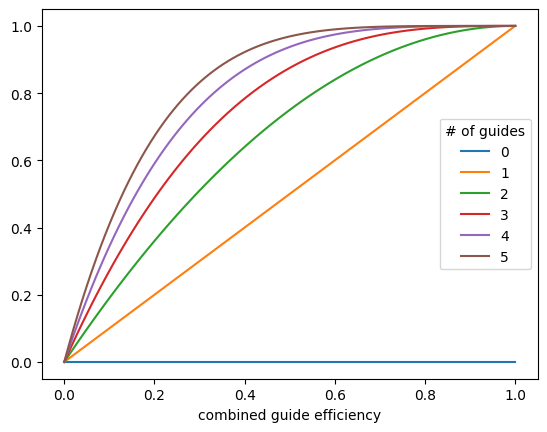

In [41]:
max_guides = 5
for n_guides in range(max_guides + 1):
    avg_efficiency = np.linspace(0, 1, 100)
    efficiency = np.full((n_guides, len(avg_efficiency)), avg_efficiency)
    combined_efficiency = 1 - np.prod(1 - efficiency, axis=0)
    plt.plot(avg_efficiency, combined_efficiency, label=n_guides)
plt.legend(title="# of guides")
plt.xlabel("average guide efficiency")
plt.xlabel("combined guide efficiency")

Text(0.5, 1.0, 'use max')

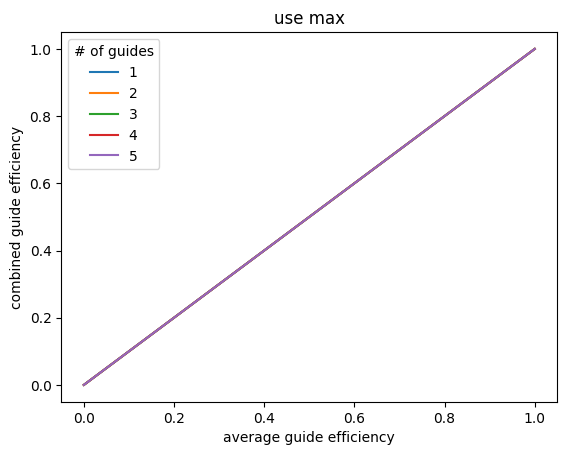

In [42]:
max_guides = 5
for n_guides in range(1, max_guides + 1):
    avg_efficiency = np.linspace(0, 1, 100)
    efficiency = np.full((n_guides, len(avg_efficiency)), avg_efficiency)
    combined_efficiency = np.max(efficiency, axis=0)
    plt.plot(avg_efficiency, combined_efficiency, label=n_guides)
plt.legend(title="# of guides")
plt.xlabel("average guide efficiency")
plt.ylabel("combined guide efficiency")
plt.title("use max")

(100,)
(100,)
(100,)
(100,)
(100,)


Text(0.5, 1.0, 'use softmax')

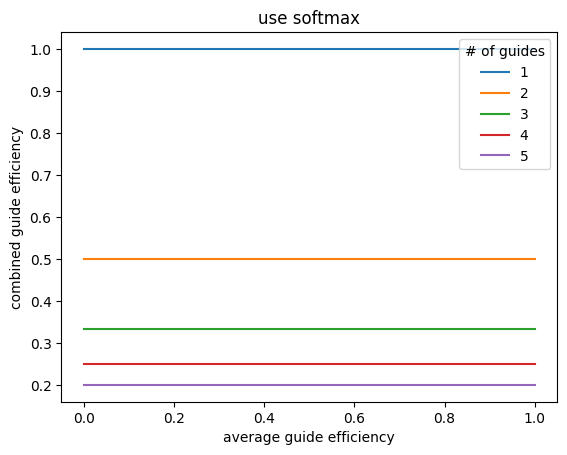

In [39]:
from scipy.special import softmax
max_guides = 5
for n_guides in range(1, max_guides + 1):
    avg_efficiency = np.linspace(0, 1, 100)
    efficiency = np.full((n_guides, len(avg_efficiency)), avg_efficiency)
    combined_efficiency = softmax(efficiency, axis=0)[0,:]
    print(combined_efficiency.shape)
    plt.plot(avg_efficiency, combined_efficiency, label=n_guides)
plt.legend(title="# of guides")
plt.xlabel("average guide efficiency")
plt.ylabel("combined guide efficiency")
plt.title("use softmax")

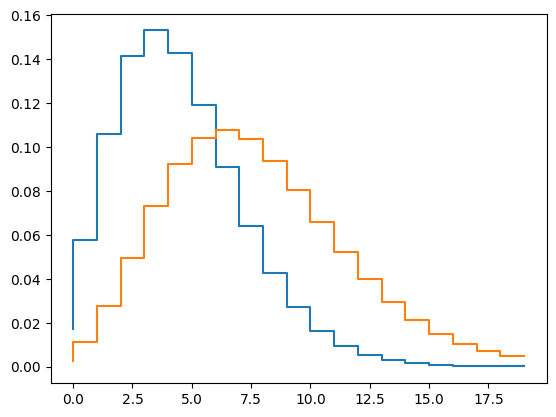

In [77]:
from turtle import title
from pyro.distributions import NegativeBinomial
import torch

k = torch.arange(20)
disp = 10
mean = 5
beta = 0.5

plt.step(k, NegativeBinomial(total_count=disp, logits=np.log(mean) - np.log(disp)).log_prob(k).exp(), label="control")
plt.step(
    k,
    NegativeBinomial(total_count=disp, logits=np.log(mean) + beta - np.log(disp)).log_prob(k).exp(),
    label="perturbed",
)


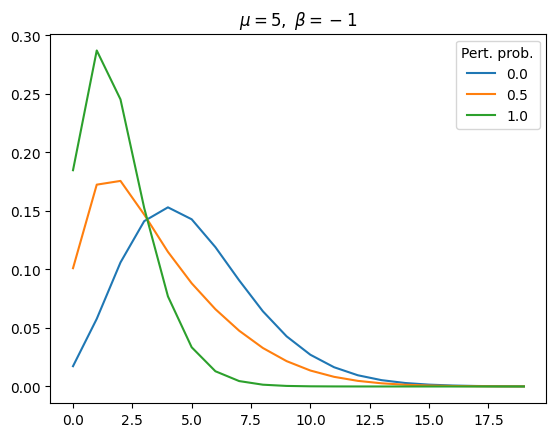

In [120]:
from pyro.distributions import NegativeBinomial, Poisson

import torch


def calc_probs(
    mean,
    beta,
    pert_prob,
    disp=None,
    k_max=20,
    likelihood="Poisson"
):
    k = torch.arange(k_max)
    if likelihood == "Poisson":
        control_mu = np.log(mean) - np.log(disp)
        pert_mu = control_mu + beta
        control_probs = NegativeBinomial(total_count=disp, logits=control_mu).log_prob(k).exp()
        pert_probs = NegativeBinomial(total_count=disp, logits=pert_mu).log_prob(k).exp()
    elif likelihood == "NegBin":
        control_mu = np.log(mean)
        pert_mu = control_mu + beta
        control_probs = Poisson(logits=control_mu).log_prob(k).exp()
        pert_probs = Poisson(logits=pert_mu).log_prob(k).exp()
    else:
        raise NotImplementedError()
    return control_probs * (1 - pert_prob) + pert_probs * pert_prob


def plot_densities(
    mean,
    beta,
    disp=None,
    k_max=20,
    mix_prob_step=0.5,
    plot_fn=plt.plot,
):
    plt.title(rf"$\mu={mean},~ \beta={beta}$")
    for pert_prob in np.arange(0, 1.001, step=mix_prob_step):
        mix_probs = calc_probs(mean, beta, pert_prob, disp=disp, k_max=k_max, likelihood=likelihood)
        # plt.step(k, mix_probs, label=np.round(pert_prob, 1))
        plot_fn(
            k,
            mix_probs,
            label=np.round(pert_prob, 1),
        )

    plt.legend(title="Pert. prob.")
    plt.show()


plot_densities(mean=5, disp=10, beta=-1)

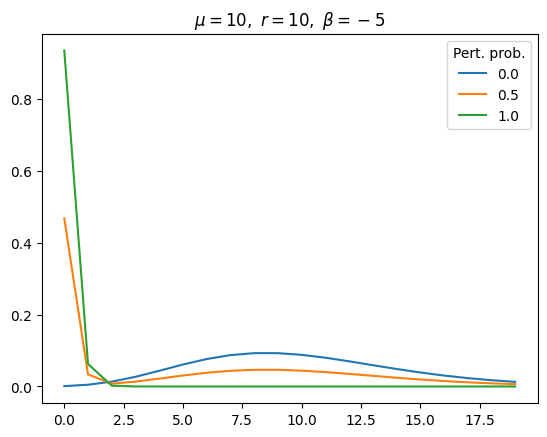

In [112]:
plot_densities(mean=10, disp=10, beta=-5, plot_fn=plt.plot)

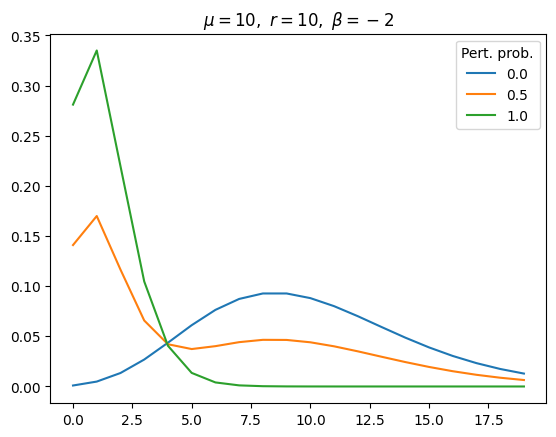

In [113]:
plot_densities(mean=10, disp=10, beta=-2)

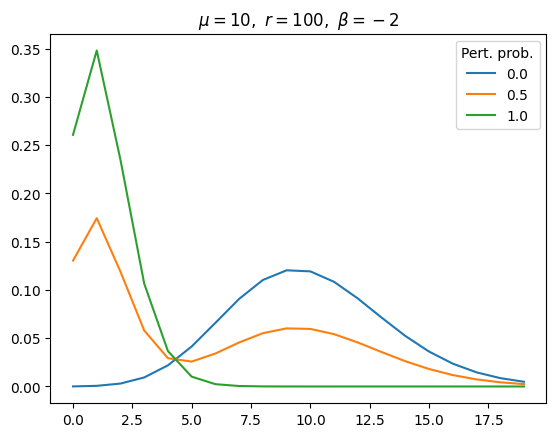

In [116]:
plot_densities(mean=10, disp=100, beta=-2)